In [ ]:
# ============================================================
# COLAB SETUP: Install dependencies & download dataset
# ============================================================
!pip install -q pyarrow fastparquet

# Download the dataset from Kaggle using opendatasets
!pip install -q opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption", data_dir="/content/data")

print("\n✅ Setup complete! Dataset downloaded to /content/data/")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.1 MB/s eta 0:00:00
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sagartmahadik
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption


100%|██████████| 11.4M/11.4M [00:02<00:00, 5.48MB/s]




✅ Setup complete! Dataset downloaded to /content/data/


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')

In [ ]:
import glob

# Find the parquet file (handles the typo in the original filename)
parquet_files = glob.glob("/content/data/**/*.parquet", recursive=True) + \
                glob.glob("/content/data/**/*.paruqet", recursive=True)

if parquet_files:
    data_path = parquet_files[0]
    print(f"Found data file: {data_path}")
else:
    data_path = "/content/data/hourly-energy-consumption/est_hourly.paruqet"
    print(f"Using default path: {data_path}")

df = pd.read_parquet(data_path)
print(f"Dataset shape: {df.shape}")
df.head()

Found data file: /content/data/hourly-energy-consumption/est_hourly.paruqet
Dataset shape: (178262, 12)


,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
Datetime,,,,,,,,,,,,
1998-12-31 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1998-12-31 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
1998-12-31 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
1998-12-31 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
1998-12-31 05:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


In [ ]:
# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Get start and end dates for each series, ignoring NaN
date_ranges = pd.DataFrame({
    "start": df.apply(lambda x: x.dropna().index.min()),
    "end": df.apply(lambda x: x.dropna().index.max())
})

# Remove time component, keep only date
date_ranges["start"] = date_ranges["start"].dt.date
date_ranges["end"] = date_ranges["end"].dt.date

# Add start and end years for sorting
date_ranges["start_year"] = pd.DatetimeIndex(date_ranges["start"]).year
date_ranges["end_year"] = pd.DatetimeIndex(date_ranges["end"]).year

# Calculate approximate duration in years
date_ranges["duration_years"] = date_ranges["end_year"] - date_ranges["start_year"]

# Sort by start year and reset index
date_ranges = date_ranges.sort_values("start_year").reset_index()
date_ranges = date_ranges.rename(columns={"index": "series_name"})

print(date_ranges)

   series_name       start         end  start_year  end_year  duration_years
0     PJM_Load  1998-04-01  2002-01-01        1998      2002               4
1         PJME  2002-01-01  2018-08-03        2002      2018              16
2         PJMW  2002-04-01  2018-08-03        2002      2018              16
3          AEP  2004-10-01  2018-08-03        2004      2018              14
4           NI  2004-05-01  2011-01-01        2004      2011               7
5       DAYTON  2004-10-01  2018-08-03        2004      2018              14
6          DUQ  2005-01-01  2018-08-03        2005      2018              13
7          DOM  2005-05-01  2018-08-03        2005      2018              13
8        COMED  2011-01-01  2018-08-03        2011      2018               7
9           FE  2011-06-01  2018-08-03        2011      2018               7
10        DEOK  2012-01-01  2018-08-03        2012      2018               6
11        EKPC  2013-06-01  2018-08-03        2013      2018               5

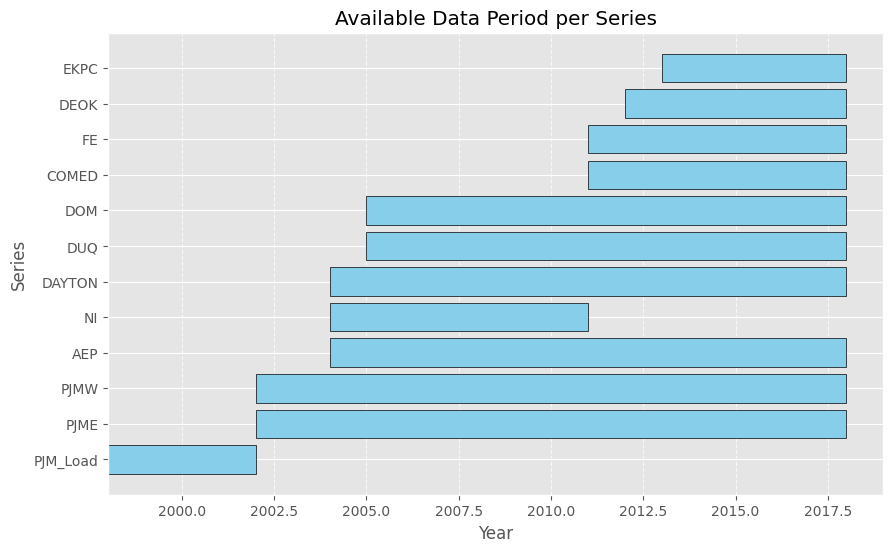

In [ ]:
plt.figure(figsize=(10, 6))

for i, row in date_ranges.iterrows():
    plt.barh(
        y=row["series_name"],
        width=row["duration_years"],
        left=row["start_year"],
        color='skyblue',
        edgecolor='black'
    )

plt.xlabel("Year")
plt.ylabel("Series")
plt.title("Available Data Period per Series")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AEP,121273.0,15499.513717,2591.399065,9581.0,13630.0,15310.0,17200.00,25695.0
COMED,66497.0,11420.152112,2304.139517,7237.0,9780.0,11152.0,12510.00,23753.0
DAYTON,121275.0,2037.851140,393.403153,982.0,1749.0,2009.0,2279.00,3746.0
DEOK,57739.0,3105.096486,599.859026,907.0,2687.0,3013.0,3449.00,5445.0
DOM,116189.0,10949.203625,2413.946569,1253.0,9322.0,10501.0,12378.00,21651.0
DUQ,119068.0,1658.820296,301.740640,1014.0,1444.0,1630.0,1819.00,3054.0
EKPC,45334.0,1464.218423,378.868404,514.0,1185.0,1386.0,1699.00,3490.0
FE,62874.0,7792.159064,1331.268006,0.0,6807.0,7700.0,8556.00,14032.0
NI,58450.0,11701.682943,2371.498701,7003.0,9954.0,11521.0,12896.75,23631.0
PJME,145366.0,32080.222831,6464.012166,14544.0,27573.0,31421.0,35650.00,62009.0


In [ ]:
## Replacing inf values with NaN

In [ ]:
import numpy as np
import pandas as pd
import warnings

# Convert to numeric and replace inf with NaN
df = df.apply(pd.to_numeric, errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)

In [ ]:
## Data Distribution for PJME, DOM, and by Region

In [ ]:
# TODO: Add distribution plots here
# Example:
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# df['PJME'].dropna().hist(bins=50, ax=axes[0], edgecolor='k')
# axes[0].set_title('PJME Distribution')
# plt.tight_layout()
# plt.show()

In [ ]:
## Organize, Split, Print, and Save (80% / 10% / 10%)

In [ ]:
import os, json, pickle, numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# --- (a) Sort index and create cyclical time features ---
df = df.sort_index()
df['sin_hour'] = np.sin(2 * np.pi * df.index.hour / 24.0)
df['cos_hour'] = np.cos(2 * np.pi * df.index.hour / 24.0)
df['sin_dow']  = np.sin(2 * np.pi * df.index.dayofweek / 7.0)
df['cos_dow']  = np.cos(2 * np.pi * df.index.dayofweek / 7.0)

feature_cols = ['PJME', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow']
data = df[feature_cols].dropna().astype('float32')

# --- (b) Temporal split 80/10/10 by index (no shuffling) ---
n_total = len(data)
n_train = int(n_total * 0.80)
n_val   = int(n_total * 0.10)
n_test  = n_total - n_train - n_val

train_df = data.iloc[:n_train]
val_df   = data.iloc[n_train:n_train + n_val]
test_df  = data.iloc[n_train + n_val:]

print("Raw split (rows):")
print(f"  train:       {len(train_df):>7,}  ({len(train_df)/n_total*100:5.1f}%)  {train_df.index[0]} -> {train_df.index[-1]}")
print(f"  validation:  {len(val_df):>7,}  ({len(val_df)/n_total*100:5.1f}%)  {val_df.index[0]} -> {val_df.index[-1]}")
print(f"  test:        {len(test_df):>7,}  ({len(test_df)/n_total*100:5.1f}%)  {test_df.index[0]} -> {test_df.index[-1]}")
print(f"  TOTAL:       {n_total:>7,}")

# --- (c) StandardScaler (fit only on training data) ---
scaler = StandardScaler().fit(train_df)
train_scaled = pd.DataFrame(scaler.transform(train_df), index=train_df.index, columns=feature_cols).astype('float32')
val_scaled   = pd.DataFrame(scaler.transform(val_df),   index=val_df.index,   columns=feature_cols).astype('float32')
test_scaled  = pd.DataFrame(scaler.transform(test_df),  index=test_df.index,  columns=feature_cols).astype('float32')

# --- (d) Sliding window creation ---
def make_windows(df_input, target_col='PJME', lookback=168, horizon=1, stride=1):
    """Create sliding windows for time series forecasting.

    Args:
        df_input: DataFrame with features
        target_col: Name of the target column
        lookback: Number of past timesteps as input (168 = 1 week of hourly data)
        horizon: Number of future timesteps to predict
        stride: Step size between consecutive windows

    Returns:
        X: Input windows array of shape (n_windows, lookback, n_features)
        y: Target values array of shape (n_windows,)
    """
    X, y = [], []
    arr = df_input.values
    target_idx = df_input.columns.get_loc(target_col)
    n = len(df_input)
    for i in range(lookback, n - horizon + 1, stride):
        X.append(arr[i - lookback:i, :])
        y.append(arr[i + horizon - 1, target_idx])
    return np.asarray(X, dtype='float32'), np.asarray(y, dtype='float32')

lookback = 168  # 1 week of hourly data
X_train, y_train = make_windows(train_scaled, lookback=lookback)
X_val, y_val     = make_windows(val_scaled,   lookback=lookback)
X_test, y_test   = make_windows(test_scaled,  lookback=lookback)

# Print window counts
total_windows = len(X_train) + len(X_val) + len(X_test)
pct = lambda k: 100 * k / total_windows if total_windows else 0
print("\nWindows (after lookback):")
print(f"  train:       {len(X_train):>7,}  ({pct(len(X_train)):5.1f}%)")
print(f"  validation:  {len(X_val):>7,}  ({pct(len(X_val)):5.1f}%)")
print(f"  test:        {len(X_test):>7,}  ({pct(len(X_test)):5.1f}%)")
print(f"  TOTAL:       {total_windows:>7,}")

# --- (e) Save artifacts ---
np.savez_compressed(
    "data_windows.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    cols=np.array(feature_cols),
    lookback=np.array([lookback], dtype=np.int32)
)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

meta = {
    "cols": feature_cols,
    "lookback": lookback,
    "split_type": "temporal_80_10_10",
    "rows": {"total": int(n_total), "train": int(len(train_df)), "val": int(len(val_df)), "test": int(len(test_df))},
    "date_ranges": {
        "train": [str(train_df.index[0]), str(train_df.index[-1])],
        "val":   [str(val_df.index[0]),   str(val_df.index[-1])],
        "test":  [str(test_df.index[0]),  str(test_df.index[-1])]
    },
    "windows": {"train": int(len(X_train)), "val": int(len(X_val)), "test": int(len(X_test))}
}
with open("meta.json", "w") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"\nArtifacts saved in: {Path('.').resolve()}")

Raw split (rows):
  train:       116,292  ( 80.0%)  2002-01-01 01:00:00+00:00 -> 2015-04-09 14:00:00+00:00
  validation:   14,536  ( 10.0%)  2015-04-09 15:00:00+00:00 -> 2016-12-05 05:00:00+00:00
  test:         14,538  ( 10.0%)  2016-12-05 06:00:00+00:00 -> 2018-08-03 00:00:00+00:00
  TOTAL:       145,366

Windows (after lookback):
  train:       116,124  ( 80.2%)
  validation:   14,368  (  9.9%)
  test:         14,370  (  9.9%)
  TOTAL:       144,862

Artifacts saved in: /content


In [ ]:
## Load Saved Split Files

In [ ]:
import pickle, numpy as np, json
from pathlib import Path

# Load scaler (needed to invert back to original scale later)
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Load windowed arrays
npz = np.load("data_windows.npz", allow_pickle=True)
X_train, y_train = npz["X_train"], npz["y_train"]
X_val, y_val     = npz["X_val"],   npz["y_val"]
X_test, y_test   = npz["X_test"],  npz["y_test"]
feature_cols     = list(npz["cols"])
lookback         = int(npz["lookback"][0])

with open("meta.json") as f:
    meta = json.load(f)

print("Loaded successfully:")
print(f"  X_train: {X_train.shape}  | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"  lookback: {lookback}, cols: {feature_cols}")

Loaded successfully:
  X_train: (116124, 168, 5)  | y_train: (116124,)
  X_val:   (14368, 168, 5)  | y_val:   (14368,)
  X_test:  (14370, 168, 5)  | y_test:  (14370,)
  lookback: 168, cols: [np.str_('PJME'), np.str_('sin_hour'), np.str_('cos_hour'), np.str_('sin_dow'), np.str_('cos_dow')]


In [ ]:
## Train and Save the LSTM Model

In [ ]:
# ==== Environment Setup ====
import os, time, tensorflow as tf
from pathlib import Path

# Reduce TF verbosity
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Detect and report GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print(f"✅ GPU detected: {gpus[0].name}")
    except Exception as e:
        print("⚠️ Could not set memory growth:", e)
else:
    print("⚠️ No GPU detected: running on **CPU** (training will be slower).")

# ==== Model Definition ====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Custom layer for patching
class PatchingLayer(layers.Layer):
    def __init__(self, patch_len=16, stride=8, **kwargs):
        super().__init__(**kwargs)
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = (168 - patch_len) // stride + 1

    def call(self, x):
        # x: (batch, 5, 168)
        patches = []
        for i in range(self.num_patches):
            start = i * self.stride
            end = start + self.patch_len
            patch = x[:, :, start:end]
            patches.append(patch)
        return tf.stack(patches, axis=2)  # (batch, 5, 20, 16)

# Input
inputs = keras.Input(shape=(168, 5))

# Transpose to (batch, 5, 168)
x = layers.Permute((2, 1))(inputs)

# Create patches
x = PatchingLayer(patch_len=16, stride=8)(x)  # (batch, 5, 20, 16)

# Patch embedding
d_model = 128
x = layers.Reshape((5 * 20, 16))(x)  # (batch, 100, 16)
x = layers.Dense(d_model)(x)  # (batch, 100, 128)
x = layers.Reshape((5, 20, d_model))(x)  # (batch, 5, 20, 128)

# Positional encoding
class AddPositionalEncoding(layers.Layer):
    def __init__(self, num_patches, d_model, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(1, 1, self.num_patches, self.d_model),
            initializer='zeros',
            trainable=True,
            name='pos_emb'
        )

    def call(self, x):
        return x + self.pos_emb

x = AddPositionalEncoding(20, d_model)(x)

# Channel-independent: (batch, 5, 20, 128) -> (batch*5, 20, 128)
x = layers.Reshape((5 * 20, d_model))(x)

# 3 Transformer layers
for i in range(3):
    attn = layers.MultiHeadAttention(num_heads=8, key_dim=16, dropout=0.1)(x, x)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(256, activation='relu')(x)
    ff = layers.Dropout(0.1)(ff)
    ff = layers.Dense(d_model)(ff)
    x = layers.LayerNormalization()(x + ff)

# Output head
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(5)(x)  # One output per feature
x = layers.Reshape((5, 1))(x)

# Take first feature (target)
class SelectFirstFeature(layers.Layer):
    def call(self, x):
        return tf.squeeze(x[:, 0, :], axis=-1)

outputs = SelectFirstFeature()(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mae', 'mape']
)

model.summary()

# Train
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]
t0 = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
train_time = time.perf_counter() - t0
print(f"⏱️ Training time: {train_time:.1f}s ({train_time/60:.2f} min)")

# Save training history
pd.DataFrame(history.history).to_csv("historytst.csv", index=False)

# ==== Save Model (robust) ====
try:
    model.save("model_patch_tst.keras")
    print("✅ Model saved in .keras format")
except Exception as e:
    print(f"⚠️ Failed to save as .keras ({e}). Trying .h5...")
    model.save("model_patch_tst.h5")
    print("✅ Model saved in .h5 format")

# ==== Evaluation with Timer ====
t1 = time.perf_counter()
test_loss, test_mae, test_mape = model.evaluate(X_test, y_test, verbose=0)
eval_time = time.perf_counter() - t1
print(f"\nTest — Loss: {float(test_loss):.6f} | MAE: {float(test_mae):.6f} | MAPE: {float(test_mape):.2f}%")
print(f"⏱️ Evaluation time: {eval_time:.2f}s")

print(f"\nArtifacts saved in: {Path('.').resolve()}")

✅ GPU detected: /physical_device:GPU:0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 168, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 5, 168)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patching_layer      │ (None, 5, 20, 16) │          0 │ permute[0][0]     │
│ (PatchingLayer)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 100, 16)   │          0 │ patching_layer[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100, 128)  │      2,176 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 5, 20,     │          0 │ dense[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (None, 5, 20,     │      2,560 │ reshape_1[0][0]   │
│ (AddPositionalEnco… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 100, 128)  │          0 │ add_positional_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │     66,048 │ reshape_2[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 128)  │          0 │ reshape_2[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 100, 256)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 100, 128)  │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 466,181 (1.78 MB)

 Trainable params: 466,181 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
1815/1815 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - loss: 0.2719 - mae: 0.3211 - mape: 321.6175 - val_loss: 0.0178 - val_mae: 0.1062 - val_mape: 58.1184 - learning_rate: 0.0010
Epoch 2/35
1815/1815 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - loss: 0.0175 - mae: 0.1024 - mape: 100.6247 - val_loss: 0.0054 - val_mae: 0.0561 - val_mape: 31.4371 - learning_rate: 0.0010
Epoch 3/35
1815/1815 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step - loss: 0.0098 - mae: 0.0763 - mape: 72.5265 - val_loss: 0.0046 - val_mae: 0.0536 - val_mape: 29.4890 - learning_rate: 0.0010
Epoch 4/35
1815/1815 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step - loss: 0.0072 - mae: 0.0650 - mape: 63.4600 - val_loss: 0.0060 - val_mae: 0.0582 - val_mape: 24.6192 - learning_rate: 0.0010
Epoch 5/35
1815/1815 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - loss: 0.0064 - mae: 0.0611 - mape: 57.0203 - val_loss: 0.0039 - val_mae: 0.0497 - val_mape: 23.2734 - learning_rate: 0.0010
Epoch 6/35
1815/1815 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - loss: 0.0061 - mae: 0.0597 - m

In [ ]:
# ==== Environment Setup ====
import os, time, tensorflow as tf
from pathlib import Path

# Reduce TF verbosity
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Detect and report GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print(f"✅ GPU detected: {gpus[0].name}")
    except Exception as e:
        print("⚠️ Could not set memory growth:", e)
else:
    print("⚠️ No GPU detected: running on **CPU** (training will be slower).")

# ==== Model Definition ====
from tensorflow.keras import layers, models, callbacks
import pandas as pd

model = models.Sequential([
    layers.Input(shape=(lookback, X_train.shape[-1])),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mae', metrics=['mse'])
model.summary()

# ==== Callbacks ====
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    filepath="best_lstm.weights.h5",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# ==== Training with Timer ====
t0 = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, checkpoint],
    verbose=1
)
train_time = time.perf_counter() - t0
print(f"⏱️ Training time: {train_time:.1f}s ({train_time/60:.2f} min)")

# Save training history
pd.DataFrame(history.history).to_csv("history.csv", index=False)

# ==== Save Model (robust) ====
try:
    model.save("model_lstm.keras")
    print("✅ Model saved in .keras format")
except Exception as e:
    print(f"⚠️ Failed to save as .keras ({e}). Trying .h5...")
    model.save("model_lstm.h5")
    print("✅ Model saved in .h5 format")

# ==== Evaluation with Timer ====
t1 = time.perf_counter()
test_mae, test_mse = model.evaluate(X_test, y_test, verbose=0)
eval_time = time.perf_counter() - t1
print(f"\nTest — MAE: {float(test_mae):.6f} | MSE: {float(test_mse):.6f}")
print(f"⏱️ Evaluation time: {eval_time:.2f}s")

print(f"\nArtifacts saved in: {Path('.').resolve()}")

✅ GPU detected: /physical_device:GPU:0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2828 - mse: 0.1781
Epoch 1: val_loss improved from None to 0.10638, saving model to best_lstm.weights.h5

Epoch 1: finished saving model to best_lstm.weights.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.1855 - mse: 0.0757 - val_loss: 0.1064 - val_mse: 0.0195
Epoch 2/100
451/454 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1075 - mse: 0.0200
Epoch 2: val_loss improved from 0.10638 to 0.08481, saving model to best_lstm.weights.h5

Epoch 2: finished saving model to best_lstm.weights.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0996 - mse: 0.0175 - val_loss: 0.0848 - val_mse: 0.0120
Epoch 3/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0809 - mse: 0.0119
Epoch 3: val_loss improved from 0.08481 to 0.05582, saving model to best_lstm.weights.h5

Epoch 3: finished saving model to best_lstm.weights.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0761 - mse: 0.0106 - val_loss: 0.0558 - val_mse: 0


DEFINING CUSTOM LAYERS FOR MODEL LOADING
✅ Custom layers defined

CHECKING AVAILABLE MODEL FILES
Available model files:
  1. model_patch_tst.keras
  2. best_lstm.weights.h5
  3. model_lstm.keras

LOADING TRAINED MODELS FOR COMPARISON
✅ LSTM model loaded from .keras

⚠️ Attempting to load PatchTST from: model_patch_tst.keras
✅ PatchTST model loaded successfully

🔮 Generating predictions...

PERFORMANCE METRICS COMPARISON

LSTM Performance:
  MAE:  0.029240
  MSE:  0.001711
  RMSE: 0.041359
  R²:   0.998086
  MAPE: 19.04%

PatchTST Performance:
  MAE:  0.022730
  MSE:  0.000955
  RMSE: 0.030909
  R²:   0.998931
  MAPE: 14.63%

MODEL COMPARISON SUMMARY
MAE   — LSTM:   0.0292 | PatchTST:   0.0227 | Δ: -22.26% | Winner: PatchTST
MSE   — LSTM:   0.0017 | PatchTST:   0.0010 | Δ: -44.15% | Winner: PatchTST
RMSE  — LSTM:   0.0414 | PatchTST:   0.0309 | Δ: -25.27% | Winner: PatchTST
MAPE  — LSTM:  19.0373 | PatchTST:  14.6281 | Δ: -23.16% | Winner: PatchTST

R² Score — LSTM: 0.9981 | PatchTST: 

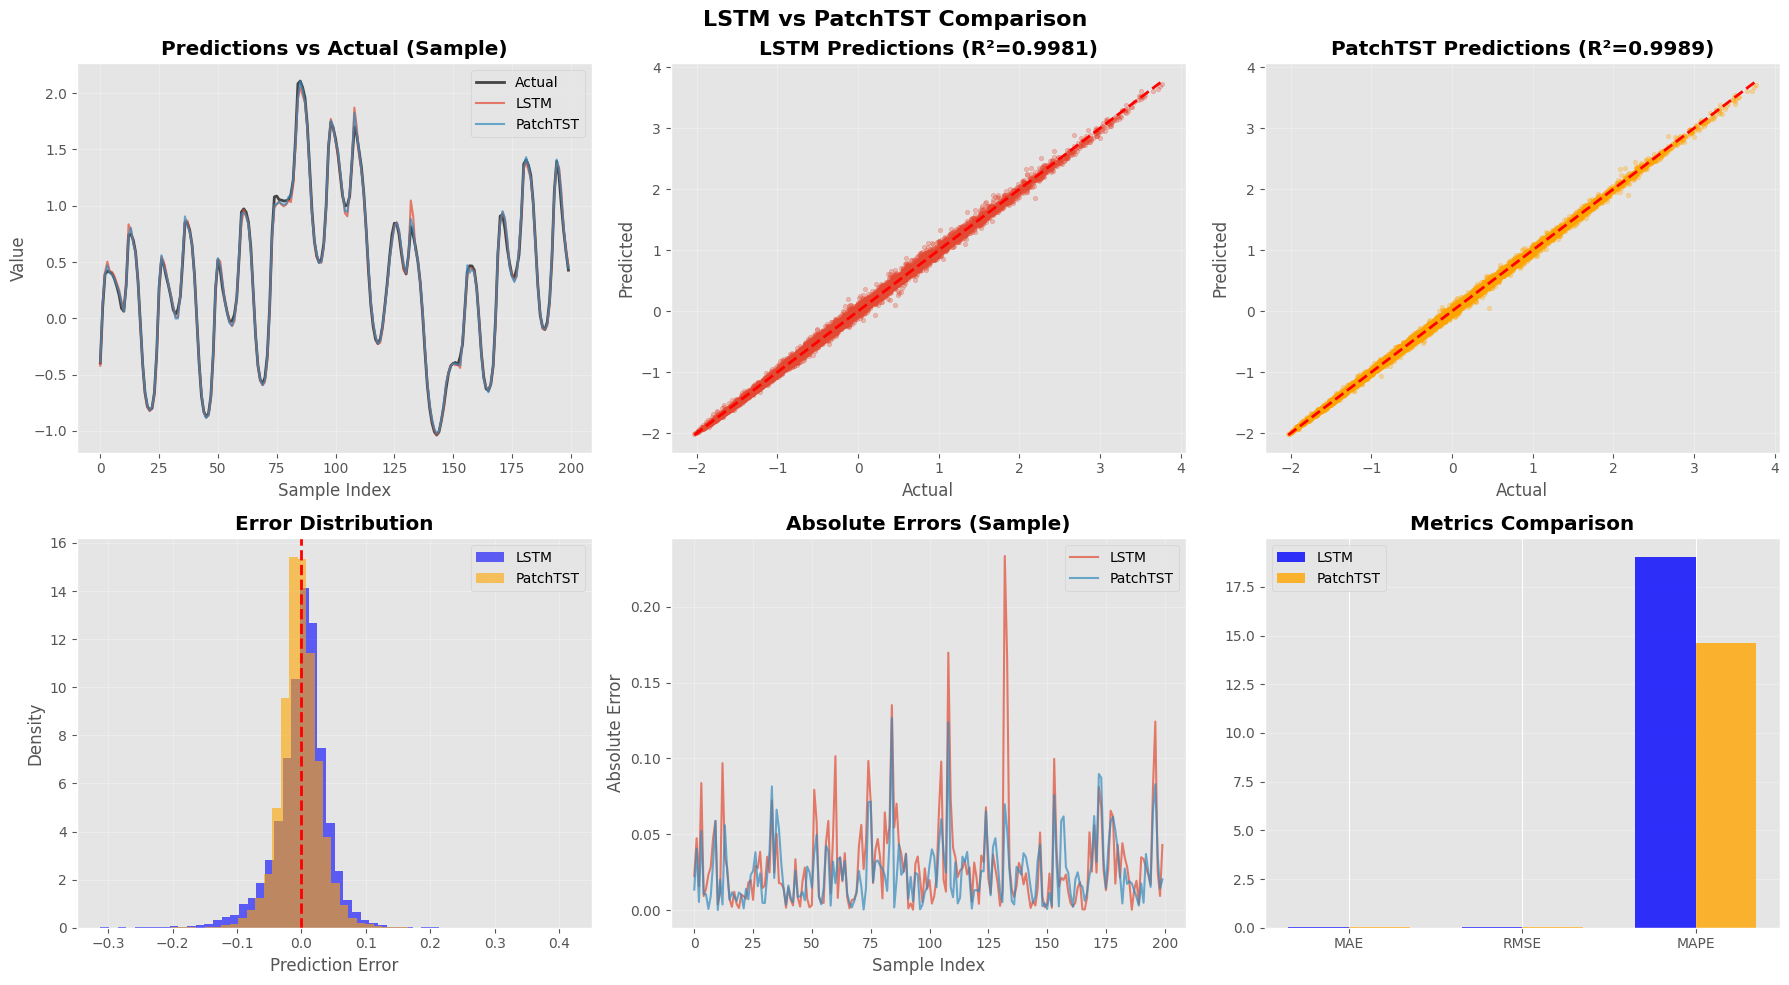


📊 Found history files: ['history.csv']
⚠️ PatchTST history file not found - skipping training curve comparison

FINAL RECOMMENDATION
🏆 PatchTST outperforms LSTM by 22.26% in MAE
   Recommended for deployment if inference speed is acceptable.

📊 Trade-off Summary:
   Accuracy:   PatchTST wins
   Speed:      PatchTST wins (127% faster)
   Simplicity: LSTM wins (simpler architecture)
   Parameters: LSTM wins (30,369 vs 466,181)



In [ ]:
# ==== POST-TRAINING COMPARISON MODULE ====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import os

# ==== 0. Define Custom Layers for PatchTST Model ====
print("\n" + "="*60)
print("DEFINING CUSTOM LAYERS FOR MODEL LOADING")
print("="*60)

from tensorflow.keras import layers

# Custom layer for patching
class PatchingLayer(layers.Layer):
    def __init__(self, patch_len=16, stride=8, **kwargs):
        super().__init__(**kwargs)
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = (168 - patch_len) // stride + 1

    def call(self, x):
        patches = []
        for i in range(self.num_patches):
            start = i * self.stride
            end = start + self.patch_len
            patch = x[:, :, start:end]
            patches.append(patch)
        return tf.stack(patches, axis=2)

    def get_config(self):
        config = super().get_config()
        config.update({
            "patch_len": self.patch_len,
            "stride": self.stride
        })
        return config

# Positional encoding layer
class AddPositionalEncoding(layers.Layer):
    def __init__(self, num_patches, d_model, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(1, 1, self.num_patches, self.d_model),
            initializer='zeros',
            trainable=True,
            name='pos_emb'
        )

    def call(self, x):
        return x + self.pos_emb

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "d_model": self.d_model
        })
        return config

# Output selection layer
class SelectFirstFeature(layers.Layer):
    def call(self, x):
        return tf.squeeze(x[:, 0, :], axis=-1)

    def get_config(self):
        return super().get_config()

print("✅ Custom layers defined")

# ==== 1. Check Available Model Files ====
print("\n" + "="*60)
print("CHECKING AVAILABLE MODEL FILES")
print("="*60)

model_files = [f for f in os.listdir('.') if f.endswith(('.keras', '.h5'))]
print("Available model files:")
for i, f in enumerate(model_files, 1):
    print(f"  {i}. {f}")

# ==== 2. Load Both Models ====
print("\n" + "="*60)
print("LOADING TRAINED MODELS FOR COMPARISON")
print("="*60)

# Load LSTM model
try:
    lstm_model = tf.keras.models.load_model("model_lstm.keras")
    print("✅ LSTM model loaded from .keras")
except:
    lstm_model = tf.keras.models.load_model("model_lstm.h5")
    print("✅ LSTM model loaded from .h5")

# Load PatchTST model - UPDATE THIS FILENAME IF DIFFERENT
patchtst_filename = "model_patch_tst.keras"  # ⚠️ CHANGE THIS IF YOUR FILE HAS A DIFFERENT NAME

print(f"\n⚠️ Attempting to load PatchTST from: {patchtst_filename}")

try:
    # Load with custom objects
    patchtst_model = tf.keras.models.load_model(
        patchtst_filename,
        custom_objects={
            'PatchingLayer': PatchingLayer,
            'AddPositionalEncoding': AddPositionalEncoding,
            'SelectFirstFeature': SelectFirstFeature
        }
    )
    print(f"✅ PatchTST model loaded successfully")
except FileNotFoundError:
    # Try .h5 if .keras fails
    try:
        patchtst_filename = patchtst_filename.replace('.keras', '.h5')
        patchtst_model = tf.keras.models.load_model(
            patchtst_filename,
            custom_objects={
                'PatchingLayer': PatchingLayer,
                'AddPositionalEncoding': AddPositionalEncoding,
                'SelectFirstFeature': SelectFirstFeature
            }
        )
        print(f"✅ PatchTST model loaded from .h5")
    except Exception as e:
        print(f"\n❌ ERROR: Could not load PatchTST model")
        print(f"   Tried: {patchtst_filename}")
        print(f"   Error: {e}")
        print(f"\n   Available files: {model_files}")
        raise SystemExit("Fix the filename and re-run.")

# ==== 3. Generate Predictions ====
print("\n🔮 Generating predictions...")
t0 = time.perf_counter()
lstm_preds = lstm_model.predict(X_test, verbose=0).flatten()
lstm_pred_time = time.perf_counter() - t0

t0 = time.perf_counter()
patchtst_preds = patchtst_model.predict(X_test, verbose=0).flatten()
patchtst_pred_time = time.perf_counter() - t0

y_test_flat = y_test.flatten()

# ==== 4. Calculate Comprehensive Metrics ====
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"\n{model_name} Performance:")
    print(f"  MAE:  {mae:.6f}")
    print(f"  MSE:  {mse:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  R²:   {r2:.6f}")
    print(f"  MAPE: {mape:.2f}%")

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2, "MAPE": mape}

print("\n" + "="*60)
print("PERFORMANCE METRICS COMPARISON")
print("="*60)

lstm_metrics = calculate_metrics(y_test_flat, lstm_preds, "LSTM")
patchtst_metrics = calculate_metrics(y_test_flat, patchtst_preds, "PatchTST")

# ==== 5. Comparison Summary ====
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

metrics_names = ["MAE", "MSE", "RMSE", "MAPE"]
for metric in metrics_names:
    lstm_val = lstm_metrics[metric]
    patchtst_val = patchtst_metrics[metric]
    diff_pct = ((patchtst_val - lstm_val) / lstm_val) * 100

    winner = "PatchTST" if patchtst_val < lstm_val else "LSTM"
    print(f"{metric:5s} — LSTM: {lstm_val:8.4f} | PatchTST: {patchtst_val:8.4f} | Δ: {diff_pct:+6.2f}% | Winner: {winner}")

print(f"\nR² Score — LSTM: {lstm_metrics['R²']:.4f} | PatchTST: {patchtst_metrics['R²']:.4f}")

# ==== 6. Inference Speed Comparison ====
print("\n" + "="*60)
print("INFERENCE SPEED COMPARISON")
print("="*60)
print(f"LSTM:     {lstm_pred_time:.4f}s ({len(X_test)/lstm_pred_time:.0f} samples/sec)")
print(f"PatchTST: {patchtst_pred_time:.4f}s ({len(X_test)/patchtst_pred_time:.0f} samples/sec)")
speedup = lstm_pred_time / patchtst_pred_time
print(f"Speedup:  {speedup:.2f}x {'(PatchTST faster)' if speedup > 1 else '(LSTM faster)'}")

# ==== 7. Model Complexity Comparison ====
print("\n" + "="*60)
print("MODEL COMPLEXITY COMPARISON")
print("="*60)

lstm_params = lstm_model.count_params()
patchtst_params = patchtst_model.count_params()

print(f"LSTM Parameters:     {lstm_params:,}")
print(f"PatchTST Parameters: {patchtst_params:,}")
print(f"Ratio:               {patchtst_params/lstm_params:.2f}x {'(PatchTST larger)' if patchtst_params > lstm_params else '(LSTM larger)'}")

# ==== 8. Error Distribution Analysis ====
lstm_errors = y_test_flat - lstm_preds
patchtst_errors = y_test_flat - patchtst_preds

print("\n" + "="*60)
print("ERROR DISTRIBUTION STATISTICS")
print("="*60)
print(f"LSTM Error     — Mean: {np.mean(lstm_errors):+.6f} | Std: {np.std(lstm_errors):.6f}")
print(f"PatchTST Error — Mean: {np.mean(patchtst_errors):+.6f} | Std: {np.std(patchtst_errors):.6f}")

# ==== 9. Visualizations ====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LSTM vs PatchTST Comparison', fontsize=16, fontweight='bold')

# Plot 1: Predictions vs Actual
ax = axes[0, 0]
sample_range = slice(0, 200)
ax.plot(y_test_flat[sample_range], label='Actual', linewidth=2, alpha=0.7, color='black')
ax.plot(lstm_preds[sample_range], label='LSTM', linewidth=1.5, alpha=0.7)
ax.plot(patchtst_preds[sample_range], label='PatchTST', linewidth=1.5, alpha=0.7)
ax.set_title('Predictions vs Actual (Sample)', fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Value')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Scatter - LSTM
ax = axes[0, 1]
ax.scatter(y_test_flat, lstm_preds, alpha=0.3, s=10)
ax.plot([y_test_flat.min(), y_test_flat.max()],
        [y_test_flat.min(), y_test_flat.max()], 'r--', linewidth=2)
ax.set_title(f'LSTM Predictions (R²={lstm_metrics["R²"]:.4f})', fontweight='bold')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.grid(alpha=0.3)

# Plot 3: Scatter - PatchTST
ax = axes[0, 2]
ax.scatter(y_test_flat, patchtst_preds, alpha=0.3, s=10, color='orange')
ax.plot([y_test_flat.min(), y_test_flat.max()],
        [y_test_flat.min(), y_test_flat.max()], 'r--', linewidth=2)
ax.set_title(f'PatchTST Predictions (R²={patchtst_metrics["R²"]:.4f})', fontweight='bold')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.grid(alpha=0.3)

# Plot 4: Error Distribution
ax = axes[1, 0]
ax.hist(lstm_errors, bins=50, alpha=0.6, label='LSTM', density=True, color='blue')
ax.hist(patchtst_errors, bins=50, alpha=0.6, label='PatchTST', density=True, color='orange')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Error Distribution', fontweight='bold')
ax.set_xlabel('Prediction Error')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# Plot 5: Absolute Error Comparison
ax = axes[1, 1]
abs_errors_lstm = np.abs(lstm_errors)
abs_errors_patchtst = np.abs(patchtst_errors)
ax.plot(abs_errors_lstm[:200], label='LSTM', alpha=0.7, linewidth=1.5)
ax.plot(abs_errors_patchtst[:200], label='PatchTST', alpha=0.7, linewidth=1.5)
ax.set_title('Absolute Errors (Sample)', fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Absolute Error')
ax.legend()
ax.grid(alpha=0.3)

# Plot 6: Metrics Bar Chart
ax = axes[1, 2]
metrics_to_plot = ['MAE', 'RMSE', 'MAPE']
x = np.arange(len(metrics_to_plot))
width = 0.35
lstm_vals = [lstm_metrics[m] for m in metrics_to_plot]
patchtst_vals = [patchtst_metrics[m] for m in metrics_to_plot]
ax.bar(x - width/2, lstm_vals, width, label='LSTM', alpha=0.8, color='blue')
ax.bar(x + width/2, patchtst_vals, width, label='PatchTST', alpha=0.8, color='orange')
ax.set_title('Metrics Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
print("\n✅ Comparison plots saved as 'model_comparison.png'")
plt.show()

# ==== 10. Training History Comparison ====
try:
    import pandas as pd
    history_files = [f for f in os.listdir('.') if 'history' in f.lower() and f.endswith('.csv')]
    print(f"\n📊 Found history files: {history_files}")

    # Try to load both histories
    lstm_hist_file = next((f for f in history_files if 'lstm' in f.lower()), 'history.csv')
    patchtst_hist_file = next((f for f in history_files if 'patch' in f.lower() or 'tst' in f.lower()), None)

    if os.path.exists(lstm_hist_file):
        lstm_history = pd.read_csv(lstm_hist_file)

        if patchtst_hist_file and os.path.exists(patchtst_hist_file):
            patchtst_history = pd.read_csv(patchtst_hist_file)

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Loss curves
            ax = axes[0]
            ax.plot(lstm_history['loss'], label='LSTM Train', linewidth=2, color='blue')
            ax.plot(lstm_history['val_loss'], label='LSTM Val', linewidth=2, linestyle='--', color='blue')
            ax.plot(patchtst_history['loss'], label='PatchTST Train', linewidth=2, color='orange')
            ax.plot(patchtst_history['val_loss'], label='PatchTST Val', linewidth=2, linestyle='--', color='orange')
            ax.set_title('Training Loss Comparison', fontweight='bold', fontsize=14)
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend()
            ax.grid(alpha=0.3)

            # Metric curves
            ax = axes[1]
            metric_col = 'mae' if 'mae' in lstm_history.columns else ('mse' if 'mse' in lstm_history.columns else None)

            if metric_col:
                ax.plot(lstm_history[metric_col], label=f'LSTM Train {metric_col.upper()}', linewidth=2, color='blue')
                ax.plot(lstm_history.get(f'val_{metric_col}', lstm_history['val_loss']),
                        label=f'LSTM Val {metric_col.upper()}', linewidth=2, linestyle='--', color='blue')

                if metric_col in patchtst_history.columns:
                    ax.plot(patchtst_history[metric_col], label=f'PatchTST Train {metric_col.upper()}', linewidth=2, color='orange')
                    ax.plot(patchtst_history.get(f'val_{metric_col}', patchtst_history['val_loss']),
                            label=f'PatchTST Val {metric_col.upper()}', linewidth=2, linestyle='--', color='orange')

                ax.set_title(f'Training {metric_col.upper()} Comparison', fontweight='bold', fontsize=14)
                ax.set_xlabel('Epoch')
                ax.set_ylabel(metric_col.upper())
                ax.legend()
                ax.grid(alpha=0.3)

            plt.tight_layout()
            plt.savefig('training_history_comparison.png', dpi=150, bbox_inches='tight')
            print("✅ Training history comparison saved")
            plt.show()
        else:
            print("⚠️ PatchTST history file not found - skipping training curve comparison")
    else:
        print("⚠️ No history files found - skipping training curve comparison")

except Exception as e:
    print(f"⚠️ Could not compare training histories: {e}")

# ==== 11. Final Recommendation ====
print("\n" + "="*60)
print("FINAL RECOMMENDATION")
print("="*60)

if patchtst_metrics["MAE"] < lstm_metrics["MAE"]:
    improvement = ((lstm_metrics["MAE"] - patchtst_metrics["MAE"]) / lstm_metrics["MAE"]) * 100
    print(f"🏆 PatchTST outperforms LSTM by {improvement:.2f}% in MAE")
    print(f"   Recommended for deployment if inference speed is acceptable.")
else:
    improvement = ((patchtst_metrics["MAE"] - lstm_metrics["MAE"]) / lstm_metrics["MAE"]) * 100
    print(f"🏆 LSTM outperforms PatchTST by {-improvement:.2f}% in MAE")
    print(f"   LSTM is simpler, faster, and performs better - recommended for deployment.")

# Trade-off summary
print("\n📊 Trade-off Summary:")
print(f"   Accuracy:   {'PatchTST' if patchtst_metrics['MAE'] < lstm_metrics['MAE'] else 'LSTM'} wins")
print(f"   Speed:      {'PatchTST' if speedup > 1 else 'LSTM'} wins ({abs(speedup-1)*100:.0f}% faster)")
print(f"   Simplicity: LSTM wins (simpler architecture)")
print(f"   Parameters: {'LSTM' if lstm_params < patchtst_params else 'PatchTST'} wins ({min(lstm_params, patchtst_params):,} vs {max(lstm_params, patchtst_params):,})")

print("\n" + "="*60)

In [ ]:
# ==== SAVE TO GOOGLE DRIVE ====
from google.colab import drive
import shutil
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive')

# Create save directory in Google Drive
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
project_name = "lstm_vs_patchtst"
gdrive_save_path = f"/content/drive/MyDrive/colab_experiments/{project_name}_{timestamp}"

os.makedirs(gdrive_save_path, exist_ok=True)
print(f"📁 Created directory in Google Drive: {gdrive_save_path}")

# Copy all files
print("\n📤 Copying files to Google Drive...")

# Models
for f in [f for f in os.listdir('.') if f.endswith(('.keras', '.h5', '.weights.h5'))]:
    shutil.copy(f, gdrive_save_path)
    print(f"   ✅ {f}")

# History files
for f in [f for f in os.listdir('.') if 'history' in f.lower() and f.endswith('.csv')]:
    shutil.copy(f, gdrive_save_path)
    print(f"   ✅ {f}")

# Plots
for f in [f for f in os.listdir('.') if f.endswith(('.png', '.jpg', '.jpeg'))]:
    shutil.copy(f, gdrive_save_path)
    print(f"   ✅ {f}")

# Save predictions and metrics (same as above)
try:
    import pandas as pd
    predictions_df = pd.DataFrame({
        'actual': y_test_flat,
        'lstm_pred': lstm_preds,
        'patchtst_pred': patchtst_preds
    })
    predictions_df.to_csv(f"{gdrive_save_path}/predictions.csv", index=False)
    print(f"   ✅ predictions.csv")
except:
    pass

print(f"\n✅ All files saved to Google Drive!")
print(f"📂 Location: {gdrive_save_path}")

Mounted at /content/drive
📁 Created directory in Google Drive: /content/drive/MyDrive/colab_experiments/lstm_vs_patchtst_20260422_192356

📤 Copying files to Google Drive...
   ✅ model_patch_tst.keras
   ✅ best_lstm.weights.h5
   ✅ model_lstm.keras
   ✅ history.csv
   ✅ model_comparison.png
   ✅ predictions.csv

✅ All files saved to Google Drive!
📂 Location: /content/drive/MyDrive/colab_experiments/lstm_vs_patchtst_20260422_192356
